| Kolom              | Deskripsi                                                                                |
| ------------------ | ---------------------------------------------------------------------------------------- |
| **date**           | Tanggal pencatatan atau penjualan rumah. Format `YYYY-MM-DD`.                            |
| **price**          | Harga jual rumah. Ini adalah **target** atau **label** yang ingin diprediksi oleh model. |
| **bedrooms**       | Jumlah kamar tidur.                                                                      |
| **bathrooms**      | Jumlah kamar mandi (termasuk pecahan, misalnya 2.25 = 2 kamar mandi + 1 toilet kecil).   |
| **sqft\_living**   | Luas bangunan dalam satuan kaki persegi (*square feet*).                                 |
| **sqft\_lot**      | Luas tanah dalam satuan kaki persegi.                                                    |
| **floors**         | Jumlah lantai bangunan.                                                                  |
| **waterfront**     | Apakah rumah berada di tepi air (1 = iya, 0 = tidak).                                    |
| **view**           | Skor atau indeks pemandangan dari rumah, biasanya 0–4 atau 0–5.                          |
| **condition**      | Kondisi rumah secara umum (biasanya skala 1–5, semakin tinggi semakin bagus).            |
| **sqft\_above**    | Luas bangunan di atas tanah (tidak termasuk basement).                                   |
| **sqft\_basement** | Luas basement (lantai bawah tanah), dalam square feet.                                   |
| **yr\_built**      | Tahun rumah dibangun.                                                                    |
| **yr\_renovated**  | Tahun terakhir rumah direnovasi (0 jika tidak pernah direnovasi).                        |
| **street**         | Alamat jalan. Biasanya bisa diabaikan atau digunakan untuk fitur tekstual tertentu.      |
| **city**           | Kota lokasi rumah.                                                                       |
| **statezip**       | Kode pos + state (misalnya: "WA 98034"). Bisa dipisah untuk analisis.                    |
| **country**        | Negara, dalam hal ini semua sepertinya "USA". Bisa diabaikan jika tidak ada variasi.     |


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
data = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\data_house.csv")

In [3]:
data.sample(3)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2599,2014-06-16 00:00:00,378000.0,5.0,2.5,2760,8015,1.0,0,0,4,1600,1160,1960,2001,13327 30th Ave NE,Seattle,WA 98125,USA
823,2014-05-16 00:00:00,523000.0,3.0,1.5,1260,3135,1.5,0,0,3,1260,0,1931,0,3200 44th Ave SW,Seattle,WA 98116,USA
2595,2014-06-16 00:00:00,699850.0,4.0,3.5,2690,6164,2.0,0,0,3,2690,0,2002,0,1010 274th Way SE,Sammamish,WA 98075,USA


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
data.shape

(4600, 18)

In [6]:
data = data.drop(['street'], axis=1)

In [7]:
data['date'] = pd.to_datetime(data['date'])

In [8]:
data['bedrooms'] = data['bedrooms'].astype(int)
data['price'] = data['price'].astype(int)
# data['bedrooms'] = data['bedrooms'].astype(int)
# data['bedrooms'] = data['bedrooms'].astype(int)

In [9]:
data.head(3)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,country
0,2014-05-02,313000,3,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,USA
1,2014-05-02,2384000,5,2.5,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,USA
2,2014-05-02,342000,3,2.0,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,USA


### Feature Engginering

In [10]:
data_model = data.copy()

In [11]:
data_model['age'] = 2025 - data_model['yr_built']
data_model['is_renovated'] = (data_model['yr_renovated'] > 0).astype(int)

In [12]:
data_model = data_model.drop(['date'], axis=1)

In [13]:
data_model[['state', 'zipcode']] = data_model['statezip'].str.split(' ', expand=True)
data_model.drop(columns='statezip', inplace=True)

In [14]:
data_model['zipcode'] = data_model['zipcode'].astype(int)

In [15]:
data_model.drop(columns='state', inplace=True)

In [16]:
data_model.drop(columns='country', inplace=True)

In [17]:
# Encoding Kolom Kategorikal
le_city = LabelEncoder()
le_state = LabelEncoder()
data_model['city'] = le_city.fit_transform(data_model['city'])

In [51]:
data_model['total_rooms'] = data_model['bedrooms'] + data_model['bathrooms']

In [52]:
data_model['living_density'] = data_model['sqft_living'] / data_model['sqft_lot']

In [53]:
data_model.sample(3)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,age,is_renovated,zipcode,total_rooms,living_density
2634,870000,4,4.25,3010,4887,2.0,0,3,4,1940,1070,1951,1996,35,74,1,98115,8.25,0.615920
2658,332000,3,2.50,1530,9406,1.0,0,0,3,1270,260,1993,0,32,32,0,98059,5.50,0.162662
2050,595000,4,2.50,1990,2175,2.0,0,0,3,1680,310,2005,0,35,20,0,98107,6.50,0.914943


### Machine Learning

In [19]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
cols = [
    'bedrooms',	'bathrooms', 'sqft_living',	'sqft_lot',	'floors',	
    'waterfront', 'view', 'condition', 'sqft_above', 
    'sqft_basement', 'yr_built', 'city', 'yr_renovated',	
    'city',	'age',	'is_renovated',	'zipcode'
]

train_data = data_model[cols]
test_data = data_model['price']

In [21]:
# Buat model dan latih
model = RandomForestRegressor()
model.fit(train_data, test_data)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
feature_importance = model.feature_importances_

# Tampilkan dalam DataFrame
importance_df = pd.DataFrame({
    'Fitur': train_data.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

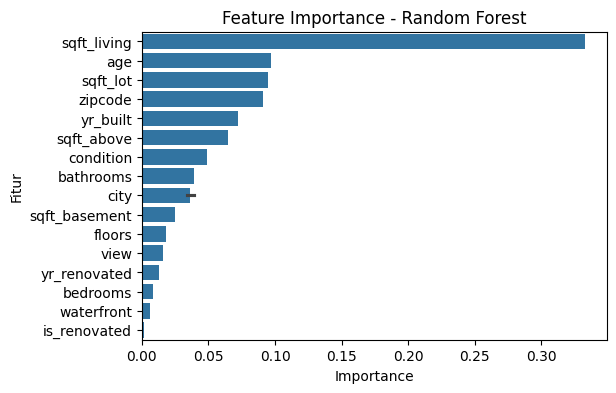

In [23]:
# Visualisasikan
plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Fitur', data=importance_df)
plt.title('Feature Importance - Random Forest')
plt.show()

#### Looking for Outlier 

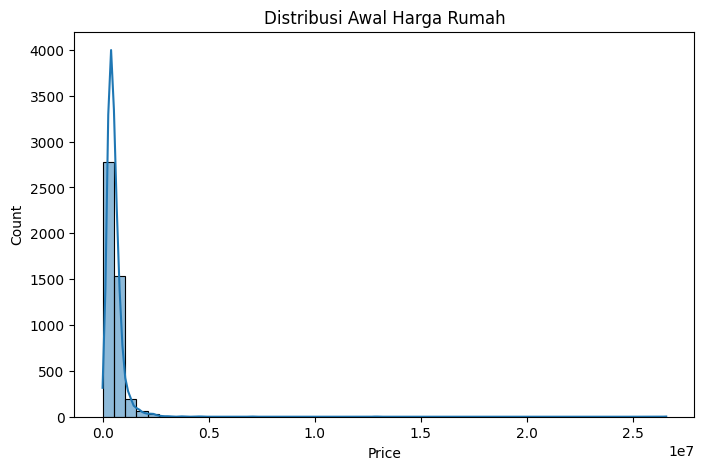

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data['price'], bins=50, kde=True)
plt.title("Distribusi Awal Harga Rumah")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [41]:
data['log_price'] = np.log(data['price'])

C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [43]:
data.sample()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,country,log_price
2429,2014-06-12,600000,3,2.25,1480,5400,2.0,0,0,4,1480,0,1914,1945,Seattle,WA 98122,USA,13.304685


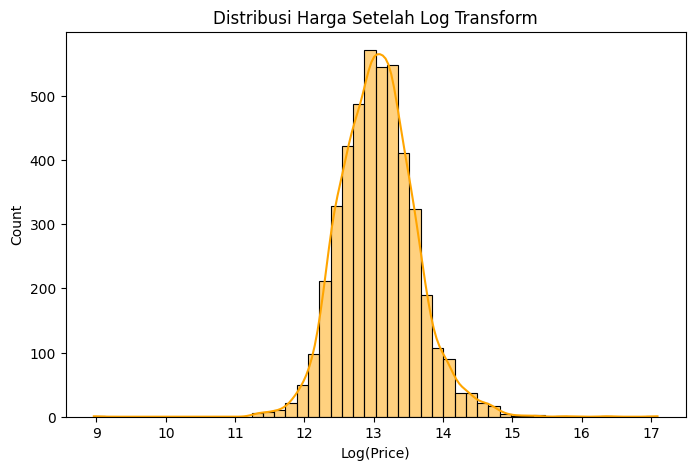

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(data['log_price'], bins=50, kde=True, color='orange')
plt.title("Distribusi Harga Setelah Log Transform")
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.show()

In [44]:
# Jika target masih log_price
correlation = data_model.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlation)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
city             0.018625
age             -0.021857
is_renovated    -0.028595
yr_renovated    -0.028774
zipcode         -0.046052
Name: price, dtype: float64


#### Choose Impacted Feature

In [45]:
# cols_train=[
#     'sqft_living',	'sqft_lot',	'yr_built',
#     'sqft_above', 'zipcode',
#     'yr_built', 'city'
# ]

cols_train=[
    'sqft_living', 'sqft_above', 'bathrooms',
    'view', 'sqft_basement', 'bedrooms'
]

# X = data.drop(columns=['price','country'])  # Fitur
X = data_model[cols_train]
y = data_model['price']                 # Target

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Tidak perlu scaled data

y_pred_rf = rf.predict(X_test)

In [50]:
def evaluate_model(y_true, y_pred, name="Model"):
    print(f"\n{name} Evaluation:")
    print(f"MAE : {mean_absolute_error(y_true, y_pred):,.2f}")
    print(f"MSE : {mean_squared_error(y_true, y_pred):,.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):,.2f}")
    print(f"R²  : {r2_score(y_true, y_pred):.4f}")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


Linear Regression Evaluation:
MAE : 220,189.52
MSE : 989,313,480,245.34
RMSE: 994,642.39
R²  : 0.0299

Random Forest Evaluation:
MAE : 234,960.36
MSE : 1,005,717,359,306.44
RMSE: 1,002,854.61
R²  : 0.0139
